In [15]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import Isomap
from finsler_embedding.utils import get_grid_pts, get_bounds
from finsler_embedding.graph import construct_distance_matrix, get_knn_graph,compute_epsilon_empirical
from finsler_embedding.operators import *
from geodesic_toolbox import SlopeMetrics
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d.axes3d import Axes3D

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
N = 3000
eps_scale = 1
m=2
def sample_data(N):
    x = torch.rand(N) * 6.4 - 3.2
    y = torch.rand(N) * 4.8 - 2.4
    X = torch.stack([x, y], dim=1)
    return X


In [17]:
class Mountain(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x1 = x[:, 0]
        x2 = x[:, 1]
        z = (0.4 * x1.sin() * x2.cos() 
             + 0.15 * torch.exp(-((x1 + 1.0) ** 2 + (x2 - 0.5) ** 2))
             - 0.15 * torch.exp(-((x1 - 1.0) ** 2 + (x2 + 0.5) ** 2))
        ) 
        return z.unsqueeze(1)


class MountainScalar(Mountain):
    """Same height map with shape (N,), as SlopeMetrics expects f: (N,2) -> (N,)."""
    def forward(self, x):
        return super().forward(x).squeeze(-1)


randers_metric = SlopeMetrics(MountainScalar())
X = sample_data(N).requires_grad_()
df =  randers_metric.df_(X)
assert (df[:,0]**2 + df[:,1]**2).max() < 1/3, "The Slope metric is not well-defined"
Z = Mountain()(X)

X_high = torch.cat([X, Z], dim=1)

In [18]:
cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)


In [19]:
def plot_surface(X,Y,Z,ax: Axes3D,use_wireframe: bool = True):
    ls = LightSource(azdeg=315, altdeg=45)
    rgb = ls.shade(
        Z,
        cmap=cmap,
        vert_exag=0.7,
        blend_mode="soft",
    )

    if use_wireframe:
        ax.plot_wireframe(
            X, Y, Z,
            rstride=5,
            cstride=5,
            linewidth=0.5,
            antialiased=True,
            # alpha=0.96,
            color="black",
        )
    else:
        ax.plot_surface(
            X, Y, Z,
            facecolors=rgb,
            rstride=2,
            cstride=2,
            linewidth=0.,
            antialiased=True,
            shade=False,
            # alpha=0.8,
        )

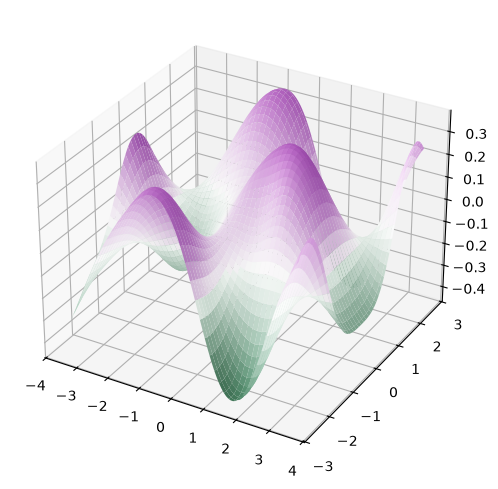

In [20]:
grid_pts = get_grid_pts(get_bounds(X_high[:,:2], margin=0.05), n_pts=100)
X_plt = grid_pts[:,0].reshape(100,100)
Y_plt = grid_pts[:,1].reshape(100,100)

# A smooth "potato-chip" surface with a few broad features
Z_plt = (
    0.38 * torch.sin(1.15 * X_plt + 0.35 * torch.cos(Y_plt))
    * torch.cos(1.25 * Y_plt)
    + 0.16 * torch.exp(-((X_plt + 1.1) ** 2 + (Y_plt - 0.35) ** 2) / 0.65)
    - 0.20 * torch.exp(-((X_plt - 0.85) ** 2 + (Y_plt + 0.55) ** 2) / 0.55)
    + 0.07 * torch.cos(0.8 * X_plt * Y_plt)
)

fig = plt.figure(figsize=(18,6))
ax = fig.add_subplot(1, 1, 1, projection="3d")
plot_surface(X_plt.numpy(),Y_plt.numpy(),Z_plt.numpy(),ax,use_wireframe=False)

In [21]:
edges = get_knn_graph(X_high, n_neighbors=10,device="cpu")
print(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X_high.requires_grad_(True), edges, randers_metric,use_approx=True)

Found 34312 edges in the KNN graph.


Computing Randers distances: 100%|██████████| 344/344 [00:00<00:00, 1252.94it/s]


In [22]:
isomap = Isomap(n_components=m, n_neighbors=10)
X_low = isomap.fit_transform(X_high.detach())
X_low = torch.from_numpy(X_low).float()
bounds = get_bounds(X_low,margin=0.3)

In [23]:
epsilon = compute_epsilon_empirical(dst_edges, scale=eps_scale)
W = apply_gaussian_kernel(edges, dst_edges, epsilon, N)
results = randers_approximation(W, epsilon, m=m,X_low=X_low)
V = results["V"]
V_normed = V / (results["c_norm_sq"].sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

In [24]:
# Sort by x coords for display
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone().detach()
V_plt = V[idx].clone().detach()
unit_V_plt = unit_V[idx].clone()
z_plt = Z[idx]

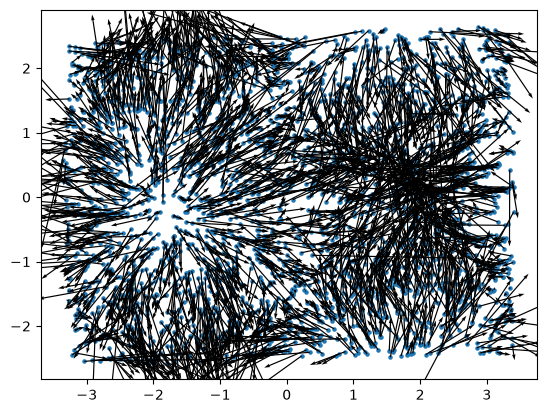

In [25]:
cbar = plt.scatter(
    X_low_plt[:, 0], X_low_plt[:, 1],s=5
)
skip=1
plt.quiver(
    X_low_plt[::skip, 0],
    X_low_plt[::skip, 1],
    # unit_V_plt[::skip, 0],
    # unit_V_plt[::skip, 1],
    V_plt[::skip, 0],
    V_plt[::skip, 1],
    color="black",
    scale=1,
    angles="xy",
    scale_units="xy",
    # alpha = results["admissible"][idx][::skip].float().sigmoid()
)

In [26]:
V = V.clone().detach()
model, loss_list = interpolate_V(X_low, V, dim=m)

  0%|          | 0/500 [00:00<?, ?it/s]

Loss: 0.0781: 100%|██████████| 500/500 [00:02<00:00, 211.92it/s]


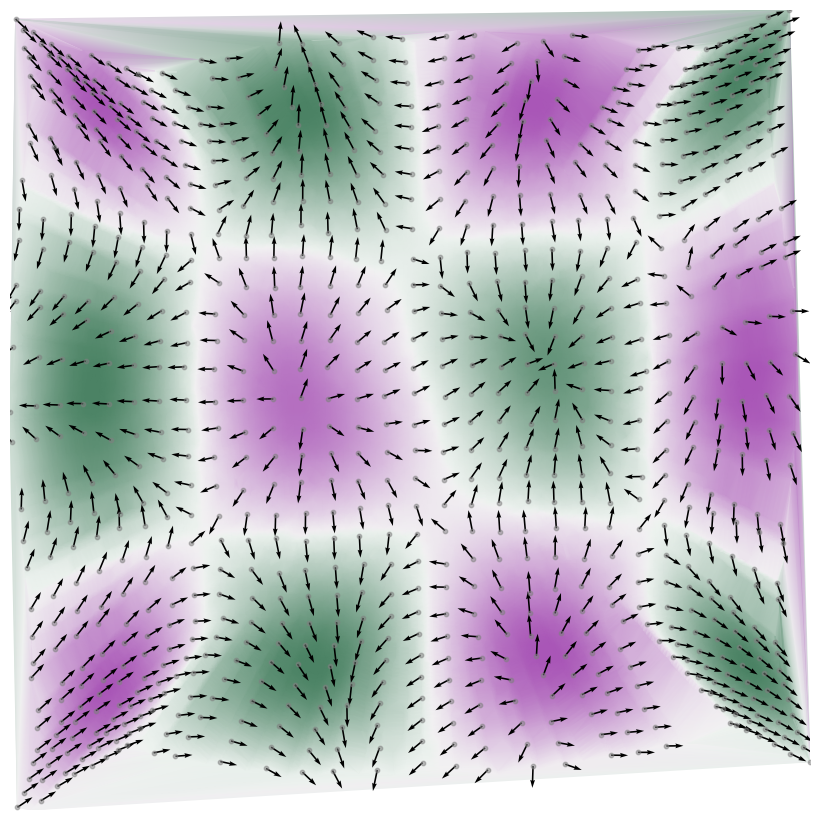

In [27]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri


# ============================================================
# Settings
# ============================================================

# Dense grid used to create the smooth background
n_surface = 150

# Coarser grid used for the vector field
n_arrows = 30

# Arrow appearance
arrow_scale = 4
arrow_width = 0.002

# ============================================================
# 1. Dense grid for the scalar field / background
# ============================================================

x = torch.linspace(bounds[0], bounds[1], n_surface)
y = torch.linspace(bounds[2], bounds[3], n_surface)

X_, Y_ = torch.meshgrid(x, y, indexing="ij")

surface_points = torch.stack(
    [X_.flatten(), Y_.flatten()],
    dim=1,
)

# Height map in the original space
with torch.no_grad():
    Z = Mountain()(surface_points)

Z = Z.detach().cpu().numpy().reshape(-1)

# ============================================================
# 2. Map the dense grid through Isomap
# ============================================================

points_grid = torch.cat([surface_points, torch.from_numpy(Z).float().unsqueeze(1)], dim=1)
surface_low = isomap.transform(
    points_grid.detach().cpu().numpy()
)

lx = surface_low[:, 0]
ly = surface_low[:, 1]


# ============================================================
# 3. Triangulate the points in Isomap space
# ============================================================

tri = mtri.Triangulation(lx, ly)


# ============================================================
# 4. Coarse grid for the vector field
# ============================================================

x_arrow = torch.linspace(bounds[0], bounds[1], n_arrows)
y_arrow = torch.linspace(bounds[2], bounds[3], n_arrows)

X_arrow, Y_arrow = torch.meshgrid(
    x_arrow,
    y_arrow,
    indexing="ij",
)

arrow_points = torch.stack(
    [
        X_arrow.flatten(),
        Y_arrow.flatten(),
    ],
    dim=1,
)
z_arrow = Mountain()(arrow_points)
# Map arrow locations through Isomap
arr_high = torch.cat([arrow_points, z_arrow], dim=1)
arrow_low = isomap.transform(
    arr_high.detach().cpu().numpy()
)

arrow_low_torch = torch.from_numpy(
    arrow_low
).float()


# ============================================================
# 5. Evaluate vector field
# ============================================================

with torch.no_grad():
    V = model(arrow_low_torch)

# Normalize vectors
V_unit = V / (
    V.norm(dim=1, keepdim=True)
    + 1e-12
)

V_unit = V_unit.cpu().numpy()


# ============================================================
# 6. Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 8),
)

# ------------------------------------------------------------
# Smooth scalar field
# ------------------------------------------------------------

tpc = ax.tripcolor(
    tri,
    Z,
    cmap=cmap,
    shading="gouraud",
)

# ------------------------------------------------------------
# Vector field
# ------------------------------------------------------------

ax.quiver(
    arrow_low[:, 0],
    arrow_low[:, 1],
    V_unit[:, 0],
    V_unit[:, 1],
    color="black",
    scale=arrow_scale,
    angles="xy",
    scale_units="xy",
    width=arrow_width,
    pivot="tail",
)

ax.scatter(
    arrow_low[:, 0],
    arrow_low[:, 1],
    color="grey",
    s=10,
    alpha=0.5
)

# ============================================================
# 7. Formatting
# ============================================================

# ax.set_aspect("equal")
ax.axis("off")
ax.margins(0)

plt.tight_layout(pad=0)
plt.savefig("matsumoto_vector_field.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

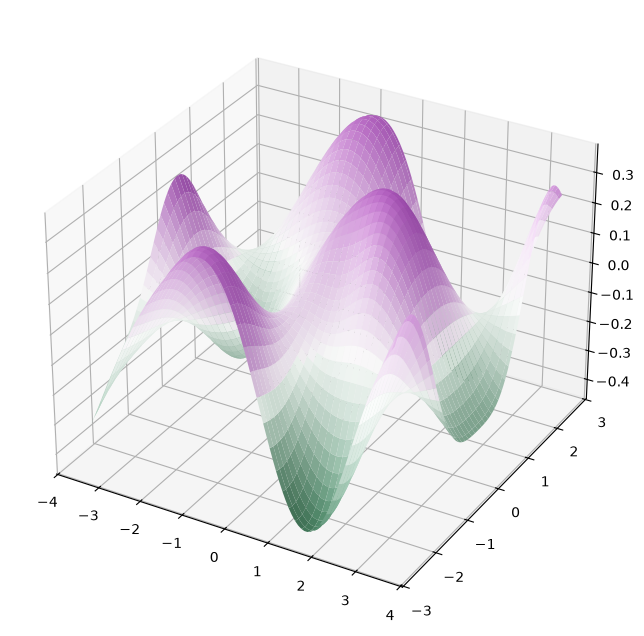

In [28]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d")
plot_surface(X_plt.numpy(),Y_plt.numpy(),Z_plt.numpy(),ax,use_wireframe=False)
fig.savefig("matsumoto_surface.pdf", bbox_inches="tight", pad_inches=0)